In [1]:
import sys
import time

In [2]:
sys.path.append("../..")

In [3]:
from matplotlib import pyplot as plt 
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from torchvision import transforms
from torch.nn import functional as F

from xaikd import models, datasets, utils, attributors
from xaikd.utils import metrics

from zennit.torchvision import ResNetCanonizer, VGGCanonizer
from zennit.composites import EpsilonGammaBox
from zennit.attribution import Gradient

from torch.utils.data import random_split

from scipy.stats import ortho_group
from datetime import datetime

In [4]:
device = utils.get_device()
device

'cuda'

In [5]:
DATASET = "imagenet-butterfly"

GAMMA = 0.25

In [6]:
dataset = datasets.construct(DATASET)

In [7]:
ds_train = dataset.create_subset(train_split=True)

ds_train, _ = random_split(
    dataset.create_subset(train_split=True),
    [0.1, 0.9]
)

We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|██████████| 7800/7800 [00:00<00:00, 2603084.91it/s]


We have 7800 images in classes [321, 322, 323, 324, 325, 326]


preparing `ImageNetButterfly` samples: 100%|███████████| 7800/7800 [00:00<00:00, 829586.45it/s]


In [18]:
def extract_activation_context(
    model,
    layer,
    dataset,
    data_loader,
    logit_modifier,
    rng,
    gamma=0.25,
    eps=1e-6,
    device="cpu",
    number_of_selected_spatial_locations=20,
    verbose=False
):
    arr_act = []
    arr_ctx = []
    
    with attributors.make_attributor_for(model, dataset.input_statistics) as attributor:
        print(f"attributor: {attributor}")
        print(f"> composite={attributor.composite}")
        print(f">> canonizers: {attributor.composite.canonizers}")

        for batch in tqdm(data_loader):
            x, y = batch
            x = x.to(device)

            try:
                module, hook = utils.interceptor.attach_hook_intercept_layer_output(
                    model, layer, should_retain_grad=True
                )

                _ = attributor.forward(x, lambda logits: logit_modifier(logits, y))

                act = utils.interceptor.get_output(module)
                rel = act.grad
                

                output_dimensions = act.shape[1:]
                # print("output.dimension", output_dimensions)
                # todo: check this with Gregoire again!
                ctx = torch.where(
                    act.abs() > 0, 
                    rel / act, 
                    0
                )

                np.testing.assert_allclose(
                    (act * ctx).detach().cpu().numpy(), 
                    (rel * (act.abs() > 0)).detach().cpu().numpy(),
                    atol=1e-6
                )

                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                if len(act.shape) == 2:
                    act = act[:, :, None, None]
                    ctx = ctx[:, :, None, None]

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)

            finally:
                hook.remove()
    if verbose:
        print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx

def get_act_ctx_for_model(
    model,                      
    layer,
    gamma=GAMMA,
    eps=1e-6,
    verbose=False
):

    logit_modifier = attributors.WinningClassOneHotEvidence(num_classes=len(dataset.selected_classes))

    rng = np.random.default_rng(seed=1)

    dl = datasets.build_dataloader(
        ds_train,
        shuffle=False
    )
    
    return extract_activation_context(
        model=model,
        layer=layer,
        dataset=dataset,
        data_loader=dl,
        logit_modifier=logit_modifier,
        rng=rng,
        device=device,
        gamma=gamma,
        eps=eps,
        verbose=verbose,
    )

In [44]:
def get_spectrum(model_name, arr_layers):

    print(f"Getting {model_name}")
    model = models.get_trained_model(model_name)
    
    utils.modify_last_layer_for_subclasses(
        model,
        dataset.selected_classes
    )

    
    model.to(device)

    
    arr_results = []
    
    for layer in arr_layers:
        arr_act, arr_ctx =  get_act_ctx_for_model(
            model,
            layer,
        )
        n, d = arr_act.shape
        n_samples = n / 20
    
        eigvals_act = np.linalg.eigvalsh(arr_act.T @ arr_act / n_samples).tolist()[::-1]
    
        eigvals_ctx = np.linalg.eigvalsh(arr_ctx.T @ arr_ctx/ n_samples).tolist()[::-1]
    
        eigvals_ccov = np.linalg.eigvalsh(
            (arr_act.T @ arr_ctx +  arr_ctx.T @ arr_act) / n_samples
        )
        eigvals_ccov = sorted(np.abs(eigvals_ccov))[::-1]
        
        arr_results.append(
            (eigvals_act, eigvals_ctx, eigvals_ccov)
        )

    del model
    torch.cuda.empty_cache()
    
    return arr_results

get_spectrum("imagenet-vgg16bn-tv", ["features.33"])

Getting imagenet-vgg16bn-tv
attributor: <zennit.attribution.Gradient object at 0x7fcaa1dcd900>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcaa1dcef50>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7fcaa1dcdb70>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:11<00:00,  1.17it/s]


[([26.342365264892578,
   3.0162696838378906,
   2.465571880340576,
   2.035834312438965,
   2.000131368637085,
   1.785525918006897,
   1.5612729787826538,
   1.478392481803894,
   1.4431155920028687,
   1.387709617614746,
   1.2411175966262817,
   1.1757229566574097,
   1.1445584297180176,
   0.9998628497123718,
   0.9650416970252991,
   0.912723958492279,
   0.8852581977844238,
   0.8632093071937561,
   0.817879855632782,
   0.8151890635490417,
   0.794307291507721,
   0.7683976888656616,
   0.7570655941963196,
   0.7401378750801086,
   0.7196564674377441,
   0.698991596698761,
   0.6861914396286011,
   0.6734166145324707,
   0.6370847225189209,
   0.6332852244377136,
   0.606407880783081,
   0.5843654870986938,
   0.5650060176849365,
   0.563049852848053,
   0.549584686756134,
   0.5303785800933838,
   0.5232220888137817,
   0.5058531165122986,
   0.48580315709114075,
   0.4823181629180908,
   0.47427842020988464,
   0.46843284368515015,
   0.4540519416332245,
   0.4499782621860504

Getting imagenet-vgg16-tv
attributor: <zennit.attribution.Gradient object at 0x7fcac2062f50>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcac2062bf0>
>> canonizers: []


100%|██████████████████████████████████████████████████████████| 13/13 [00:17<00:00,  1.32s/it]


attributor: <zennit.attribution.Gradient object at 0x7fcac1eaa5f0>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcac1ea9cc0>
>> canonizers: []


100%|██████████████████████████████████████████████████████████| 13/13 [00:12<00:00,  1.05it/s]


attributor: <zennit.attribution.Gradient object at 0x7fcaa172a500>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcaa172bdf0>
>> canonizers: []


...

100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.36it/s]


attributor: <zennit.attribution.Gradient object at 0x7fcaa17601c0>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcaa1761ab0>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7fcaa1763370>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.36it/s]


attributor: <zennit.attribution.Gradient object at 0x7fcac42b0880>
> composite=<zennit.composites.EpsilonGammaBox object at 0x7fcac42b0400>
>> canonizers: [<zennit.torchvision.VGGCanonizer object at 0x7fcac42b11b0>]


100%|██████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.37it/s]


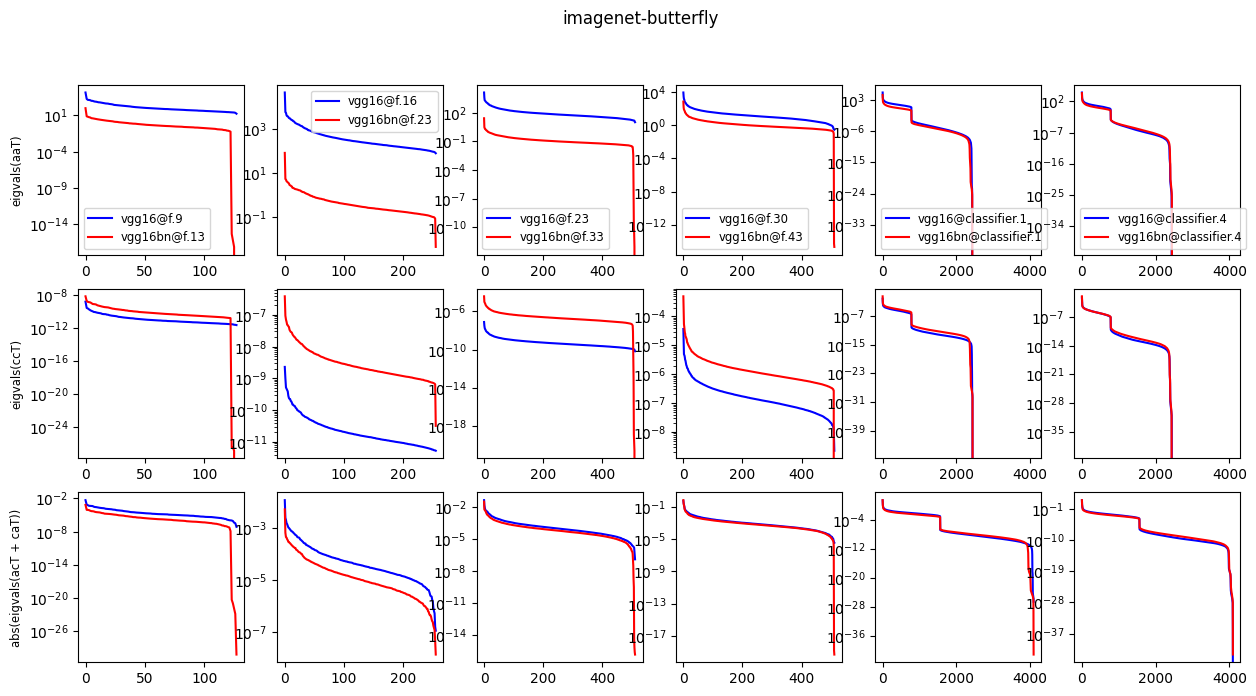

In [48]:
def viz_spectrum_pairs(
    arr_model_layers
):

    assert len(arr_model_layers[0][1]) == len(arr_model_layers[1][1])

    ncols = len(arr_model_layers[0][1])
    nrows = 3
    
    arr_stats = []

    for model_name, arr_layers in arr_model_layers:
        arr_stats.append(
            get_spectrum(model_name, arr_layers)
        )

    arr_row_names = ["eigvals(aaT)", "eigvals(ccT)", "abs(eigvals(acT + caT))"]

    plt.figure(figsize=(2.5*ncols, 2.5*nrows))
    plt.suptitle(f"{dataset}")
    
    for rix in range(nrows):
        for cix in range(ncols):
            plt.subplot(nrows, ncols, rix*ncols + cix+1)
            for _ix, (model_name, arr_layers) in enumerate(arr_model_layers):
                data = arr_stats[_ix][cix][rix]
                color = "b" if _ix == 0 else "r"
                _, name, _ = model_name.split("-")
                layer_name = arr_layers[cix].replace("features", "f")
                plt.plot(data, color=color, label=f"{name}@{layer_name}")

            if cix == 0:
                plt.ylabel(arr_row_names[rix], fontsize="smaller")
        
            plt.yscale("log")

            if rix == 0:
                plt.legend(fontsize="smaller")
    
viz_spectrum_pairs(
    arr_model_layers=[
        ("imagenet-vgg16-tv",   ["features.9", "features.16", "features.23", "features.30", "classifier.1", "classifier.4"]),
        ("imagenet-vgg16bn-tv", ["features.13","features.23", "features.33", "features.43", "classifier.1", "classifier.4"]),
    ]
)

In [47]:
print(f"Finished at {datetime.now()}")

Finished at 2024-05-09 10:27:04.021461
